In [1]:
from baseline_eval import evaluate_by_group
import pandas as pd

val = pd.read_parquet("data/processed/features_val.parquet")
y_true = val["Actual Load"]
y_pred_naive = val["Actual Load_lag_24"]

print(evaluate_by_group(y_true, y_pred_naive, val["day_of_week"], "day_of_week").to_string(index=False))

 day_of_week         mae        rmse      mape   n
           0 1699.905679 2106.909409 10.525055 312
           1  462.955996  641.893063  2.976300 312
           2  561.769663  837.660874  3.650743 288
           3  495.875463  760.048527  3.147644 312
           4  550.486818  786.718354  3.431898 312
           5 1421.552235 1772.997413 10.071792 312
           6  555.928324  747.425845  4.211700 311


Saturday's lag_24 = Friday's value → comparing a low-activity weekend day against a full-activity weekday. Bad match.

Monday's lag_24 = Sunday's value → comparing a full-activity weekday against a low-activity weekend day. Bad match, same direction.

In [1]:
import pandas as pd

df = pd.read_parquet("data/processed/val_quantile_predictions.parquet")

below_q10 = (df["actual"] < df["q10"]).mean()
above_q90 = (df["actual"] > df["q90"]).mean()

print(f"Actuals below q10: {below_q10*100:.1f}% (expected ~10%)")
print(f"Actuals above q90: {above_q90*100:.1f}% (expected ~10%)")

Actuals below q10: 11.4% (expected ~10%)
Actuals above q90: 26.4% (expected ~10%)


<Axes: xlabel='q90', ylabel='actual'>

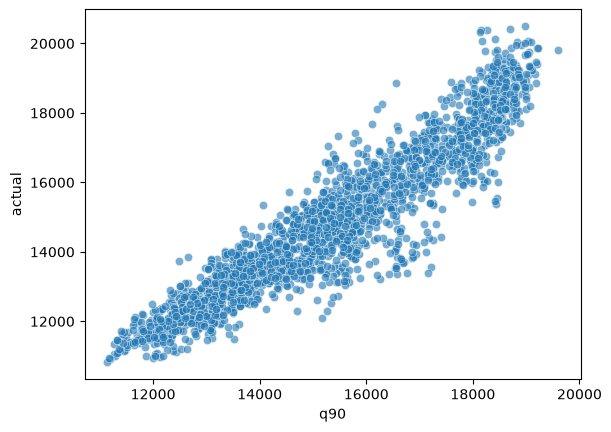

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x="q90", y="actual", alpha=0.6)

Text(0.5, 1.0, '569 rows where actual exceeded q90')

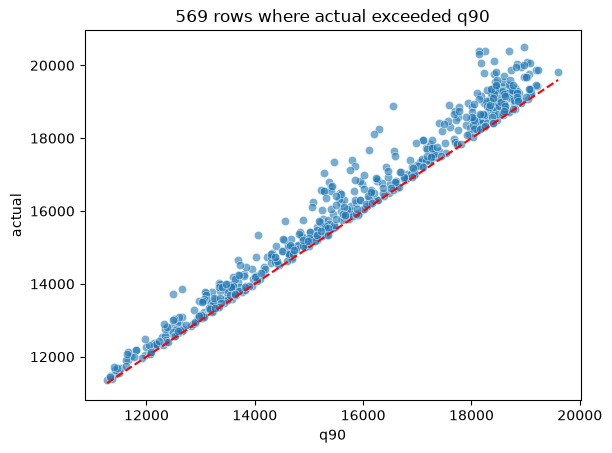

In [9]:
failures = df[df["actual"] > df["q90"]]

sns.scatterplot(data=failures, x="q90", y="actual", alpha=0.6)
plt.plot([failures["q90"].min(), failures["q90"].max()],
         [failures["q90"].min(), failures["q90"].max()], color="red", linestyle="--")
plt.title(f"{len(failures)} rows where actual exceeded q90")

In [10]:
val = pd.read_parquet("data/processed/features_val.parquet")
failures_meta = val.loc[failures.index]
print(failures_meta["hour"].value_counts().sort_index())

hour
0     17
1     18
2     16
3     21
4     24
5     25
6     26
7     20
8     25
9     32
10    26
11    22
12    22
13    18
14    19
15    22
16    25
17    39
18    30
19    29
20    28
21    23
22    22
23    20
Name: count, dtype: int64
